# Inverse Participation Ratio (IPR)

The **Inverse Participation Ratio (IPR)** is a measure used to quantify how localized a quantum state is over a lattice.

For a normalized wavefunction $\psi_i$ defined on $N$ sites, the IPR is given by:

$$
\mathrm{IPR} = \sum_{i=1}^{N} |\psi_i|^4
$$

* If the state is **extended** (spread over many sites), then $\mathrm{IPR} \sim \frac{1}{N}$ (small).
* If the state is **localized** (concentrated on few sites), then $\mathrm{IPR} \to 1$ (large).

Thus, the IPR provides a simple way to distinguish between **extended** and **localized** states in quantum systems.


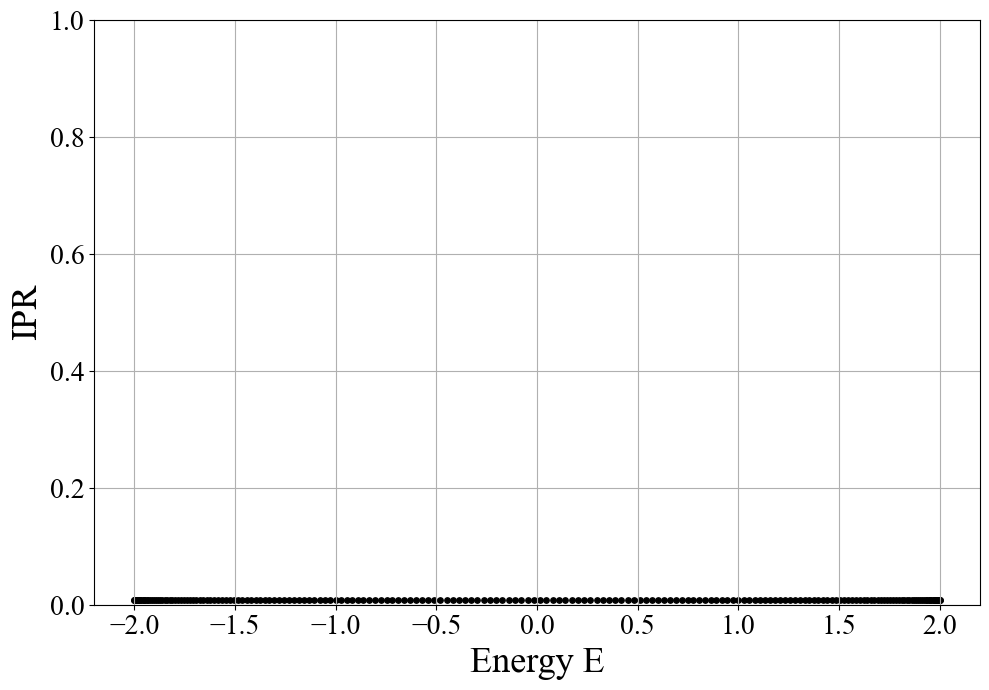

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix

# ---------------- PARAMETERS ----------------
N = 200          # number of sites
t = 1.0          # hopping

# ---------------- HAMILTONIAN ----------------
H = lil_matrix((N, N), dtype=np.float64)

for i in range(N - 1):
    H[i, i+1] = -t
    H[i+1, i] = -t

# ---------------- EIGENVALUES ----------------
H_dense = H.toarray()
eigenvalues, eigenvectors = np.linalg.eigh(H_dense)

# ---------------- IPR ----------------
energy_values = []
I_values = []

for idx in range(len(eigenvalues)):
    psi = eigenvectors[:, idx]
    I = np.sum(np.abs(psi)**4)
    
    energy_values.append(eigenvalues[idx])
    I_values.append(I)

# ---------------- PLOT ----------------
plt.figure(figsize=(10, 7))

plt.scatter(energy_values, I_values, color='black', s=15)

plt.xlabel('Energy E', fontname='Times New Roman', fontsize=26)
plt.ylabel('IPR', fontname='Times New Roman', fontsize=26)

plt.xticks(fontname='Times New Roman', fontsize=20)
plt.yticks(fontname='Times New Roman', fontsize=20)

plt.ylim(0, 1)
plt.grid(True)

plt.tight_layout()
plt.show()